#### Looking into dropsondes from the two campaigns to evaluate
- differences with radiosoundings
- mesoscale advection of $q$ and $\theta$
- further testing of simplified scheme

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 

sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
import yk22_mass_fluxes

import metpy

import meteo


import pandas as pd
from IPython.display import display, HTML

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
## constants I always need
Lv = 2.5e6  # J/kg
cp = 1004.7 # J/kg K

In [4]:
## EUREC4A dropsondes (JOANNE)
joanne = xr.open_dataset("/work/mh1498/m301248/TCO_data/dropsondes/EUREC4A/EUREC4A_JOANNE_Dropsonde-RD41_Level_4_v2.0.0.nc")#.to_dask()
joanne = joanne.sel(alt=slice(0,7000))
joanne

<xarray.Dataset> Size: 8MB
Dimensions:          (circle: 85, alt: 701, sounding: 13)
Coordinates:
  * circle           (circle) int64 680B 0 1 2 3 4 5 6 ... 78 79 80 81 82 83 84
    circle_lon       (circle) float32 340B ...
    circle_lat       (circle) float32 340B ...
    circle_time      (circle) datetime64[ns] 680B ...
    segment_id       (circle) <U12 4kB ...
  * alt              (alt) int16 1kB 0 10 20 30 40 ... 6960 6970 6980 6990 7000
  * sounding         (sounding) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/36)
    platform_id      (circle) <U4 1kB ...
    flight_altitude  (circle) float32 340B ...
    circle_diameter  (circle) float32 340B ...
    u                (circle, alt) float32 238kB ...
    dudx             (circle, alt) float32 238kB ...
    dudy             (circle, alt) float32 238kB ...
    ...               ...
    se_dtadx         (circle, alt) float32 238kB ...
    se_dtady         (circle, alt) float32 238kB ...
    se_D             (circle, alt) float32 238kB ...
    se_vor           (circle, alt) float32 238kB ...
    se_W             (circle, alt) float32 238kB ...
    omega            (circle, alt) float32 238kB ...
Attributes: (12/16)
    title:                   EUREC4A JOANNE Level-4
    doi:                     10.25326/246
    created with:            run_joanne.py doi:10.5281/zenodo.5521192
    Conventions:             CF-1.8
    campaign_id:             EUREC4A
    project_id:              JOANNE
    ...                      ...
    JOANNE_version:          2.0.0
    author:                  Geet George
    author_email:            geet.george@mpimet.mpg.de
    featureType:             trajectory
    reference:               George et al., JOANNE : Joint dropsonde Observat...
    creation_time:           2021-09-22 15:58:46.773760 UTC

In [5]:
beach = xr.open_dataset("ipfs://bafybeibgeeqs5uhmbqy4hz4v3pihrfisiklcetisxkf63d2r473szaprwi", engine="zarr")
lon_condition = (beach.circle_lon < -40) & (beach.launch_lon < -40)
beach = beach.rename({'altitude': 'alt'}).sel(alt=slice(0,7000)).where(lon_condition, drop=True)
beach

<xarray.Dataset> Size: 4GB
Dimensions:                   (circle: 46, sonde: 557, alt: 701)
Coordinates:
    circle_lat                (circle) float32 184B 12.0 7.001 ... 12.17 10.76
    circle_lon                (circle) float32 184B -50.47 -48.62 ... -56.91
    circle_time               (circle) datetime64[ns] 368B 2024-09-06T15:51:1...
    sondes_per_circle         (circle) int64 368B 12 14 14 13 12 ... 14 14 12 13
    launch_time               (sonde) datetime64[ns] 4kB 2024-09-06T15:24:33 ...
  * alt                       (alt) float64 6kB 0.0 10.0 20.0 ... 6.99e+03 7e+03
Dimensions without coordinates: circle, sonde
Data variables: (12/73)
    circle_altitude           (circle, sonde) float32 102kB 1.444e+04 ... 1.4...
    circle_id                 (circle, sonde) object 205kB 'HALO-20240906a_67...
    circle_radius             (circle, sonde) float32 102kB 1.331e+05 ... 1.3...
    div                       (circle, alt, sonde) float32 72MB 7.753e-06 ......
    div_sonde_relevance       (sonde, alt, circle) float32 72MB 1.269e-06 ......
    div_std_error             (circle, alt, sonde) float32 72MB 5.289e-06 ......
    ...                        ...
    wspd_mean                 (circle, alt, sonde) float32 72MB nan ... 7.978
    wvel                      (circle, alt, sonde) float32 72MB -0.0 ... 0.00...
    wvel_sonde_relevance      (sonde, alt, circle) float32 72MB 0.0 ... -0.00312
    wvel_std_error            (circle, alt, sonde) float32 72MB nan ... 0.000...
    x                         (sonde, alt, circle) float32 72MB -625.7 ... 5....
    y                         (sonde, alt, circle) float32 72MB 1.323e+05 ......
Attributes: (12/16)
    title:             BEACH dropsonde dataset (Level 4)
    source:            dropsondes
    creator_name:      Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    creator_email:     helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpi...
    creator_id:        https://orcid.org/0009-0007-2741-9724, https://orcid.o...
    project:           ORCESTRA, PERCUSION, MAESTRO
    ...                ...
    license:           CC-BY-4.0
    featureType:       trajectoryProfile
    keywords:          ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmosp...
    summary:           This dataset is the Level 4 BEACH dataset. It contains...
    processing_level:  4
    history:           Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 q...

### wind speed and wind divergence in circles

In [6]:
circle_wind_eu = ((joanne.u**2 + joanne.v**2)**(0.5))


wind_or = ((beach.u**2 + beach.v**2)**(0.5))
sondes_per_circle = wind_or.sondes_per_circle.values
wind_or = wind_or.isel(circle=0).squeeze()

In [7]:
means = []
sum_sondes = 0
for n_sondes in sondes_per_circle:
    chunk = wind_or.isel(sonde=slice(sum_sondes, sum_sondes + n_sondes))
    means.append(chunk.mean(dim="sonde", skipna=True))
    sum_sondes += n_sondes

circle_wind_or = xr.concat(means, dim="circle")
circle_wind_or = circle_wind_or.assign_coords(circle=beach.circle.values)

In [8]:
div_eu = ((joanne.dudx + joanne.dvdy))
div_or = ((beach.u_dudx + beach.v_dvdy)).isel(sonde=0).squeeze()

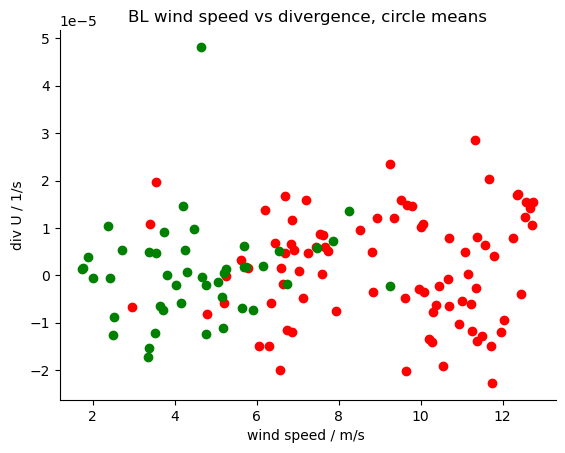

In [9]:
plt.scatter(circle_wind_eu.sel(alt=slice(200, 400)).mean(dim="alt"), div_eu.sel(alt=slice(200, 400)).mean(dim="alt"), c="red")
plt.scatter(circle_wind_or.sel(alt=slice(200, 400)).mean(dim="alt"), div_or.sel(alt=slice(200, 400)).mean(dim="alt"), c="green")

plt.title("BL wind speed vs divergence, circle means")
plt.xlabel("wind speed / m/s ")
plt.ylabel("div U / 1/s")

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

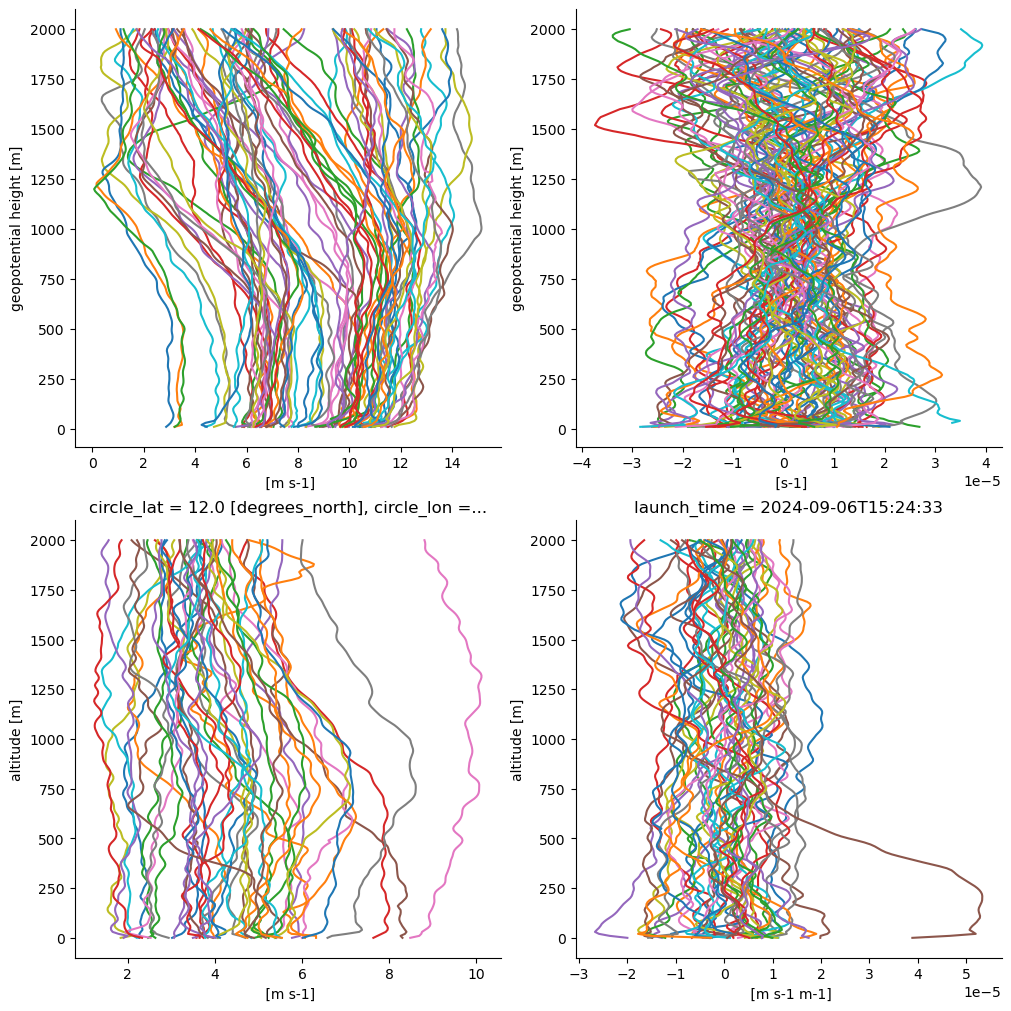

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(10,10), constrained_layout=True)

circle_wind_eu.sel(alt=slice(0, 2000)).plot.line(ax=ax[0,0], y="alt", add_legend=False)

div_eu.sel(alt=slice(0, 2000)).plot.line(ax=ax[0,1], y="alt", add_legend=False)


circle_wind_or.sel(alt=slice(0, 2000)).plot.line(ax=ax[1,0], y="alt", add_legend=False)

div_or.sel(alt=slice(0, 2000)).plot.line(ax=ax[1,1], y="alt", add_legend=False)

for x in ax.flatten():
    for spine in ['top', 'right']:
            x.spines[spine].set_visible(False)

plt.show()

In [64]:
shear_eu = (circle_wind_eu.sel(alt=slice(200, 400)).mean(dim="alt") - circle_wind_eu.sel(alt=slice(750, 1000)).mean(dim="alt") )
shear_or = (circle_wind_or.sel(alt=slice(200, 400)).mean(dim="alt") - circle_wind_or.sel(alt=slice(750, 1000)).mean(dim="alt") )

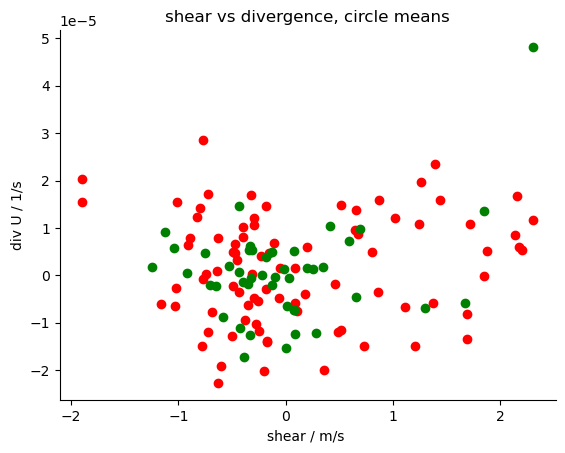

In [66]:
plt.scatter(shear_eu, div_eu.sel(alt=slice(200, 400)).mean(dim="alt"), c="red")
plt.scatter(shear_or, div_or.sel(alt=slice(200, 400)).mean(dim="alt"), c="green")

plt.title("shear vs divergence, circle means")
plt.xlabel("shear / m/s ")
plt.ylabel("div U / 1/s")

for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

#### link between ICW/RH and convergence?

In [10]:
def density(p, Ta, q_vap):
    """
    input:
    - p (Pa) pressure
    - Ta (K) air temperature
    _ q_vap (kg_kg) specific humidity

    output:
    - air density (kg_m3), without liquid water
    """
    Rd = 287.1
    T_virt = Ta*(1+0.61*q_vap)
    return p / (Rd*T_virt)

In [11]:
rho_eu = density(joanne.p, joanne.ta, joanne.q)

rho_or = density(beach.p_mean, beach.ta_mean, beach.q_mean)
rho_or = rho_or.sel(sonde=0).squeeze()

In [12]:
IWC_eu = (rho_eu*joanne.q).sum(dim="alt")*10  # 10 m is the delta_z

IWC_or = (rho_or*beach.q).sum(dim="alt")*10
IWC_or = IWC_or.sel(sonde=0).squeeze()

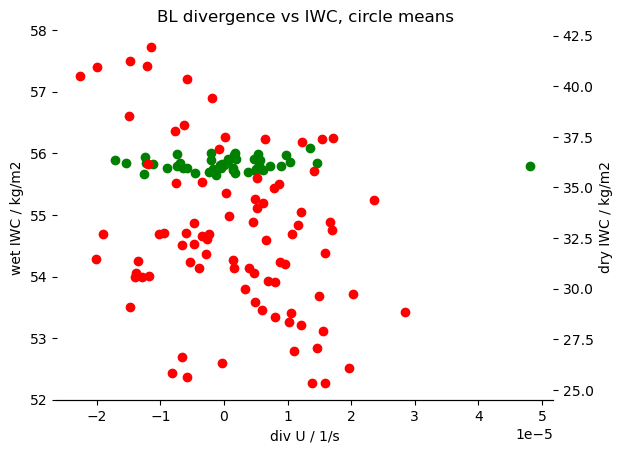

In [96]:
fig, ax = plt.subplots(1,1)

twinx = ax.twinx()
twinx.scatter( div_eu.sel(alt=slice(200, 400)).mean(dim="alt"), IWC_eu, c="red")
ax.scatter( div_or.sel(alt=slice(200, 400)).mean(dim="alt"), IWC_or, c="green")

plt.title("BL divergence vs IWC, circle means")
ax.set_ylabel("wet IWC / kg/m2 ")
twinx.set_ylabel("dry IWC / kg/m2 ")
ax.set_xlabel("div U / 1/s")

ax.set_ylim(52, 58)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
    twinx.spines[spine].set_visible(False)


### can we identify, insetad, a change in the role of BL MSE?

In [13]:
theta_eu = yk22_mass_fluxes.T_to_theta(joanne.ta, joanne.p/100.)

bl_mse_eu = (theta_eu + (Lv/cp)*(joanne.q)).sel(alt=slice(200, 400)).mean(dim="alt")
bl_mse_or = (beach.theta_mean + (Lv/cp)*(beach.q_mean)).sel(alt=slice(200, 400)).mean(dim="alt").isel(sonde=0).squeeze()

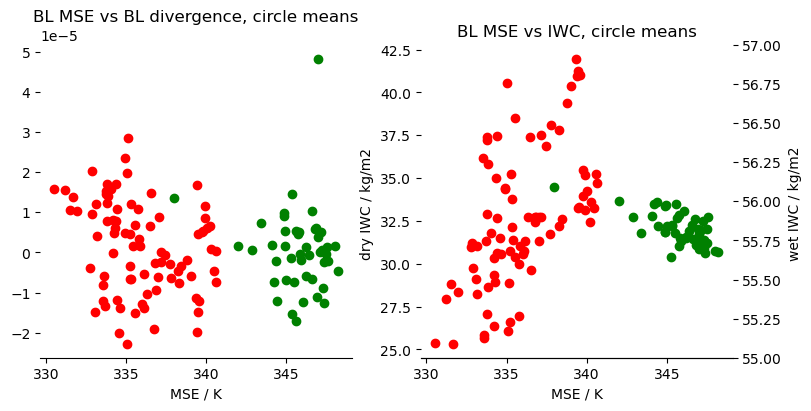

In [14]:
fig, ax = plt.subplots(1,2, figsize=(8, 4), constrained_layout=True)

ax[0].scatter(bl_mse_eu, div_eu.sel(alt=slice(200, 400)).mean(dim="alt"), c="red")
ax[0].scatter(bl_mse_or, div_or.sel(alt=slice(200, 400)).mean(dim="alt"), c="green")

ax[0].set_title("BL MSE vs BL divergence, circle means")





twinx = ax[1].twinx()
ax[1].scatter( bl_mse_eu, IWC_eu, c="red")
twinx.scatter( bl_mse_or, IWC_or, c="green")

ax[1].set_title("BL MSE vs IWC, circle means")
twinx.set_ylabel("wet IWC / kg/m2 ")
ax[1].set_ylabel("dry IWC / kg/m2 ")

twinx.set_ylim(55, 57)

for x in ax:
    x.set_xlabel("MSE / K")

    for spine in ['top', 'right', 'left']:
        x.spines[spine].set_visible(False)
        twinx.spines[spine].set_visible(False)


#### characterizing air in circles

In [37]:
def properties_from_profile_here(profile, mixed_avg_levels, entrainment_levels, downdraft_levels, CD_sat_frac, vert_dim):

    h_cd = (cp*profile["theta_mean"] + Lv*profile["q_mean"] ).sel({vert_dim:downdraft_levels})
    p_cd = profile["p_mean"].sel({vert_dim:downdraft_levels}).values/100.  ## hPa

    cd_levels = profile[vert_dim].sel({vert_dim:downdraft_levels}).values

    thetaD = (yk22_mass_fluxes.vectorized_theta_root( p_cd , h_cd, sat_frac=CD_sat_frac))
    thetaD = xr.DataArray(thetaD, dims=[vert_dim], coords={vert_dim:cd_levels, "p_cd": (vert_dim, p_cd)})
    thetaD = thetaD.rename({vert_dim:"height_cd"})

    qD = CD_sat_frac*(meteo.qsea((thetaD)-273.15 , p_cd)/1e3)
    qD = xr.DataArray(qD, dims=[vert_dim], coords={vert_dim:cd_levels, "p_cd": (vert_dim, p_cd)})
    qD = qD.rename({vert_dim:"height_cd"})



    theta_out = profile.theta.sel({vert_dim:entrainment_levels})  #.rename({vert_dim:"height_e"})
    theta_bl  = profile.theta.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim) #.rename({vert_dim:"height_e"})

    q_out = profile.q.sel({vert_dim:entrainment_levels})  #.rename({vert_dim:"height_e"})
    q_bl  = profile.q.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim) #.rename({vert_dim:"height_e"})


    return xr.Dataset(
        dict(
            thetaD=thetaD,
            qD=qD,
            theta_out=theta_out,
            theta_bl=theta_bl,
            q_out=q_out,
            q_bl=q_bl
        )
        )


In [38]:
joanne["theta"] = theta_eu

In [41]:
mixed_levels = slice(200, 400)
entrainment_levels = slice(600, 800)

downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

E_CD_eu = xr.concat(
    map(lambda i: yk22_mass_fluxes.properties_from_profile(joanne.isel(circle=i), mixed_levels, entrainment_levels, downdraft_levels_eu, CD_sat_frac=1., vert_dim="alt"),
        range(joanne.sizes["circle"])),
        dim=joanne["circle"]
)



E_CD_or = xr.concat(
    map(lambda i: properties_from_profile_here(beach.isel(circle=i, sonde=0), mixed_levels, entrainment_levels, downdraft_levels_or, CD_sat_frac=1., vert_dim="alt"),
        range(beach.sizes["circle"])),
    dim=beach["circle"]
)

/tmp/ipykernel_1306345/902124985.py:7: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  E_CD_eu = xr.concat(


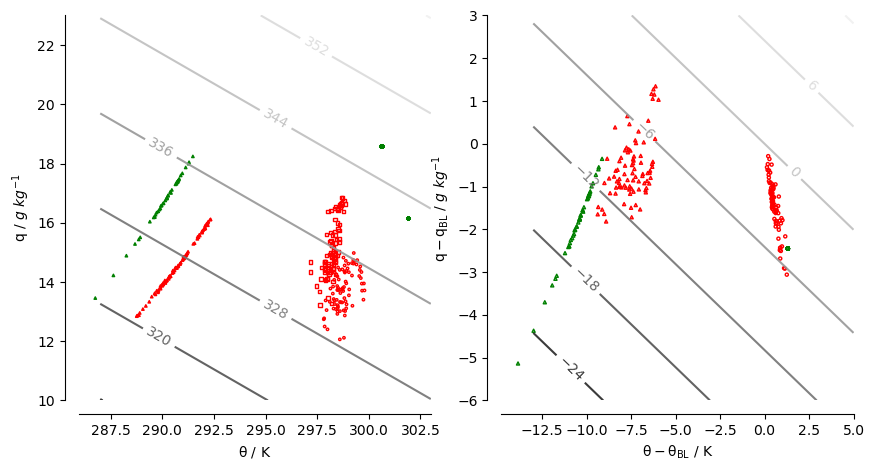

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

th, q = np.linspace(287, 303), np.linspace(0.01*1e3, 0.023*1e3)
dth, dq = np.linspace(-13, 5), np.linspace(-6.e-3*1e3, (3e-3)*1e3)
Th, Q = np.meshgrid(th, q)
DTh, DQ = np.meshgrid(dth, dq)

MSE  = (cp*Th + Lv*Q/1e3)/cp
DMSE = (cp*DTh + Lv*DQ/1e3)/cp



# absolute coords (ax[0])
ax[0].scatter(E_CD_eu["theta_bl"],        E_CD_eu["q_bl"]*1e3,       s=6,  facecolors="none",      marker="s", edgecolors="red")
ax[0].scatter((E_CD_eu["theta_out"]).mean(dim="alt"), (E_CD_eu["q_out"]*1e3).mean(dim="alt"), marker="o",s=3,  facecolors="none",edgecolors="red",)
ax[0].scatter((E_CD_eu["thetaD"]).mean(dim="height_cd"),   (E_CD_eu["qD"]*1e3).mean(dim="height_cd"),  marker="^", s=3, facecolors="none",edgecolors="red",)
ax[0].set_xlabel(r"$\rm \theta$ / K")
ax[0].set_ylabel(r"$\rm q$ / $g~kg^{-1}$")

# absolute coords (ax[0])
ax[0].scatter(E_CD_or["theta_bl"],        E_CD_or["q_bl"]*1e3,     s=3,  facecolors="none",       marker="s", edgecolors="green")
ax[0].scatter((E_CD_or["theta_out"]).mean(dim="alt"), (E_CD_or["q_out"]*1e3).mean(dim="alt"), marker="o", s=3, facecolors="none",edgecolors="green",)
ax[0].scatter((E_CD_or["thetaD"]).mean(dim="height_cd"),   (E_CD_or["qD"]*1e3).mean(dim="height_cd"),  marker="^", s=3, facecolors="none",edgecolors="green",)


cs = ax[0].contour(Th, Q, MSE, cmap="Greys_r", alpha=0.9)
ax[0].clabel(cs, inline=True)






# absolute coords (ax[0])
# ax[1].scatter(0,                0,        facecolors="none",      marker="s", edgecolors="red")
ax[1].scatter(((E_CD_eu["theta_out"]).mean(dim="alt") - E_CD_eu["theta_bl"]), ((E_CD_eu["q_out"]).mean(dim="alt") - E_CD_eu["q_bl"])*1e3, s=5, marker="o", facecolors="none",edgecolors="red",)
ax[1].scatter(((E_CD_eu["thetaD"]).mean(dim="height_cd") - E_CD_eu["theta_bl"]),   ((E_CD_eu["qD"]).mean(dim="height_cd") - E_CD_eu["q_bl"])*1e3, s=5,  marker="^", facecolors="none",edgecolors="red",)
ax[1].set_xlabel(r"$\rm \theta - \theta_{BL}$ / K")
ax[1].set_ylabel(r"$\rm q - q_{BL}$ / $g~kg^{-1}$")

# absolute coords (ax[0])
# ax[1].scatter(0,0,      facecolors="none",       marker="s", edgecolors="green")
ax[1].scatter(((E_CD_or["theta_out"]).mean(dim="alt") - E_CD_or["theta_bl"]), ((E_CD_or["q_out"]).mean(dim="alt")  - E_CD_or["q_bl"])*1e3, s=5, marker="o", facecolors="none",edgecolors="green",)
ax[1].scatter(((E_CD_or["thetaD"]).mean(dim="height_cd")- E_CD_or["theta_bl"]),   ((E_CD_or["qD"]).mean(dim="height_cd") - E_CD_or["q_bl"])*1e3, s=5,  marker="^", facecolors="none",edgecolors="green",)

cs = ax[1].contour(DTh, DQ, DMSE, cmap="Greys_r", alpha=0.9)
ax[1].clabel(cs, inline=True)



for x in ax.flatten():
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        x.spines['left'].set_position(('outward', 10))
        x.spines['bottom'].set_position(('outward', 10))


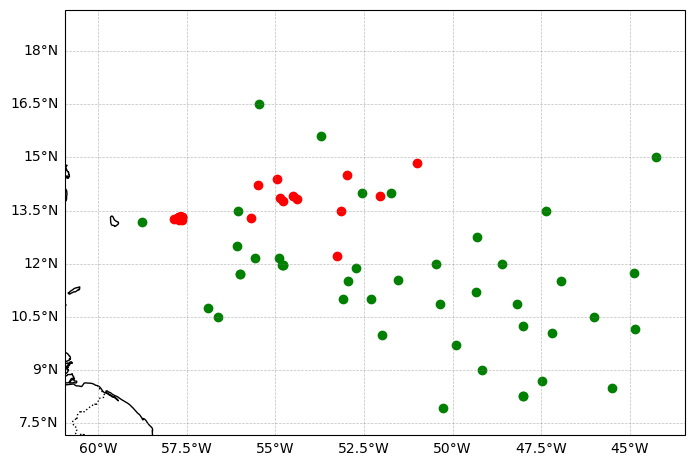

In [5]:
BCO_lon = -59.4288
BCO_lat = 13.1627

# - set control volume edges
vol_lon = [BCO_lon-0.5+360 , BCO_lon+15+360]  #[-60+360, -58+360]
vol_lat = [BCO_lat-5     , BCO_lat+5]  #[12.5, 14.5]


# - presenting area of interest

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([vol_lon[0] - 1., vol_lon[1] + 1., vol_lat[0] - 1., vol_lat[1] + 1.], crs=ccrs.PlateCarree())


gl = ax.gridlines(draw_labels=True, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

# Turn on labels on bottom and left only
gl.top_labels = False
gl.right_labels = False

# Optionally format ticks (degrees + symbols)
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()




## scatter the dropsondes lon and lat
ax.scatter(joanne.circle_lon, joanne.circle_lat, color='red', label='JOANNE Dropsondes', transform=ccrs.PlateCarree())
ax.scatter(beach.circle_lon, beach.circle_lat, color='green', label='BEACH Dropsondes', transform=ccrs.PlateCarree())



##### lower tropospheric advection terms


In [12]:
## moisture advection

q_adv_eu = - joanne.u*joanne.dqdx - joanne.v*joanne.dqdy

halo_sel = joanne.platform_id == "HALO"
q_adv_eu = q_adv_eu.where(halo_sel, drop=True)
q_adv_eu.name = 'adv_circle_mean'



u, v = beach.u.transpose( 'circle', 'alt', 'sonde' ), beach.v.transpose( 'circle', 'alt', 'sonde' )
q_adv_or_sonde = - u*beach.q_dqdx - v*beach.q_dqdy

# compute circle mean of advection
counts = beach.sondes_per_circle.values  
ends = np.cumsum(counts)                 
starts = ends - counts                   

result = []


for i, circle in enumerate(beach.circle):
    circle_mean = q_adv_or_sonde.sel(circle=circle, sonde=slice(starts[i], ends[i])).mean(dim='sonde')
    result.append(circle_mean)

q_adv_or = xr.concat(result, dim='circle')
q_adv_or.name = 'adv_circle_mean'

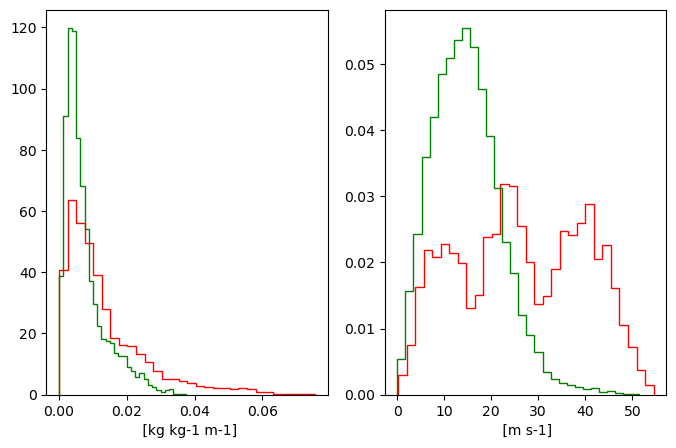

In [15]:
fig, ax = plt.subplots(1,2, figsize=(8, 5))

gkg1km = 1e3*1e3
kph = 3.6

# (joanne.dqdx*gkg1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="red")
# (joanne.dqdy*gkg1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="red")
(((joanne.dqdx**2 + joanne.dqdy**2)**(0.5))*gkg1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="red")

# (beach.q_dqdx*gkg1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True)
# (beach.q_dqdy*gkg1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True)
(((beach.q_dqdx**2 + beach.q_dqdy**2)**(0.5))*gkg1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="green")


# (joanne.u*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
# (joanne.v*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
(((joanne.u**2 + joanne.v**2)**(0.5))*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True, color="red")

# (u*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
# (v*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
(((u**2 + v**2)**(0.5))*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True, color="green")

plt.show()

In [17]:
## temperature advection

T_adv_eu = - joanne.u*joanne.dtadx - joanne.v*joanne.dtady

halo_sel = joanne.platform_id == "HALO"
T_adv_eu = T_adv_eu.where(halo_sel, drop=True)
T_adv_eu.name = 'Tadv_circle_mean'



u, v = beach.u.transpose( 'circle', 'alt', 'sonde' ), beach.v.transpose( 'circle', 'alt', 'sonde' )
T_adv_or_sonde = - u*beach.ta_dtadx - v*beach.ta_dtady

# compute circle mean of advection
counts = beach.sondes_per_circle.values  
ends = np.cumsum(counts)                 
starts = ends - counts                   

result = []

for i, circle in enumerate(beach.circle):
    circle_mean = T_adv_or_sonde.sel(circle=circle, sonde=slice(starts[i], ends[i])).mean(dim='sonde')
    result.append(circle_mean)

T_adv_or = xr.concat(result, dim='circle')
T_adv_or.name = 'Tadv_circle_mean'

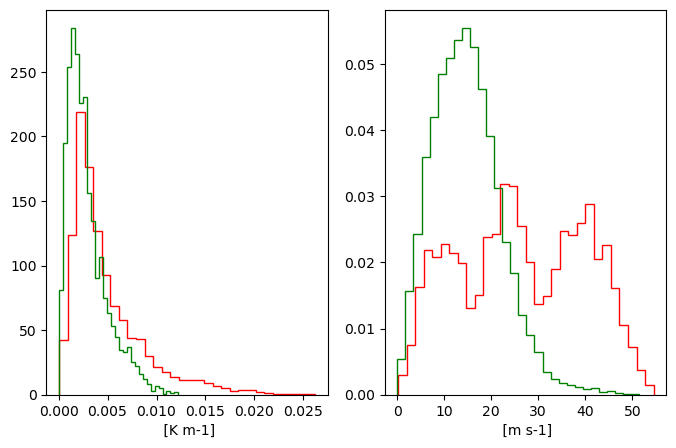

In [18]:
fig, ax = plt.subplots(1,2, figsize=(8, 5))

K1km = 1e3
kph = 3.6

# (joanne.dtadx*K1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="red")
# (joanne.dtady*K1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="red")
(((joanne.dtadx**2 + joanne.dtady**2)**(0.5))*K1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="red")

# (beach.ta_dtadx*K1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True)
# (beach.ta_dtady*K1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True)
(((beach.ta_dtadx**2 + beach.ta_dtady**2)**(0.5))*K1km).plot.hist(ax=ax[0], bins=30, histtype="step",density=True, color="green")


# (joanne.u*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
# (joanne.v*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
(((joanne.u**2 + joanne.v**2)**(0.5))*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True, color="red")

# (u*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
# (v*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True)
(((u**2 + v**2)**(0.5))*kph).plot.hist(ax=ax[1], bins=30, histtype="step",density=True, color="green")

plt.show()

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


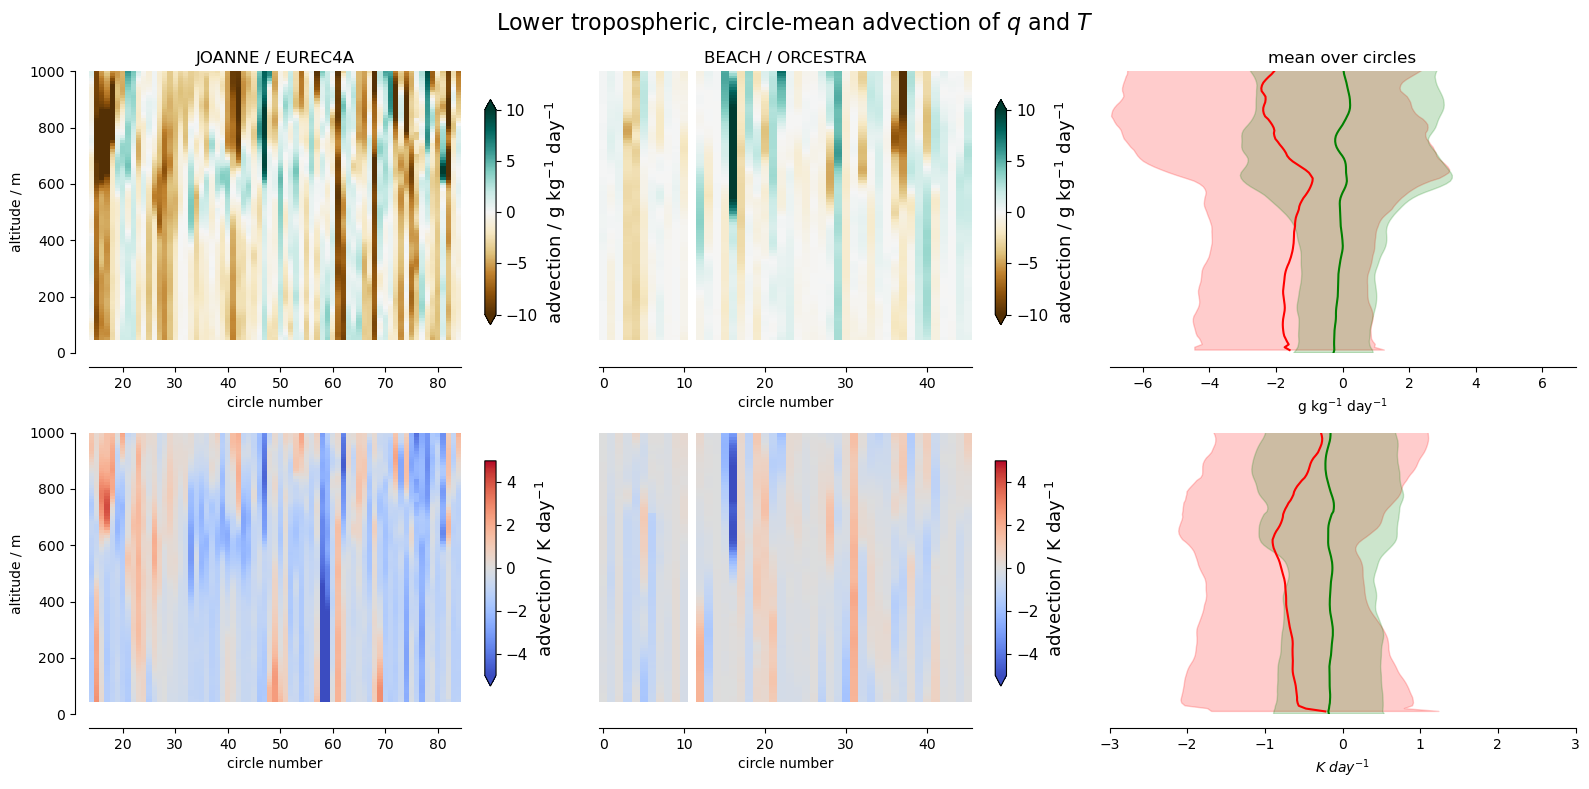

In [8]:
fig, ax = plt.subplots(2,3, figsize=(16,8))
fig.suptitle(r"Lower tropospheric, circle-mean advection of $q$ and $T$", fontsize=16)



####   moisture advection   ####

gkgday = 1e3*86400

p = (q_adv_eu*gkgday).sel(alt=slice(50, 1000)).plot(ax=ax[0,0], y="alt", vmin=-10., vmax=10., cmap='BrBG', cbar_kwargs={ 'shrink': 0.8})  # 'label': 'your label',
p.colorbar.ax.set_ylabel(r"advection / $\rm g~kg^{-1}~day^{-1}$", fontsize=13)
p.colorbar.ax.tick_params(labelsize=11)

ax[0,0].set_ylabel("altitude / m")
ax[0,0].set_title("JOANNE / EUREC4A")


p = (q_adv_or*gkgday).sel(alt=slice(50, 1000)).plot(ax=ax[0,1], y="alt", vmin=-10., vmax=10., cmap='BrBG', cbar_kwargs={ 'shrink': 0.8})  # 'label': 'your label',
p.colorbar.ax.set_ylabel(r"advection / $\rm g~kg^{-1}~day^{-1}$", fontsize=13)
p.colorbar.ax.tick_params(labelsize=11)

ax[0,1].spines["left"].set_visible(False)
ax[0,1].yaxis.set_visible(False)
ax[0,1].set_title("BEACH / ORCESTRA")

for x in [ax[0,0], ax[0,1]]:
    x.set_xlabel("circle number")





##  mean of all circles  ##

eu_mean = (q_adv_eu*gkgday).mean(dim="circle")
eu_std  = (q_adv_eu*gkgday).std(dim="circle")

or_mean = (q_adv_or*gkgday).mean(dim="circle")
or_std  = (q_adv_or*gkgday).std(dim="circle")

eu_mean.plot.line(ax=ax[0,2], y="alt", color="red",   label="JOANNE")
or_mean.plot.line(ax=ax[0,2], y="alt", color="green",  label="BEACH")
ax[0,2].fill_betweenx(eu_mean.alt, eu_mean - eu_std, eu_mean + eu_std, color="red",   alpha=0.2)
ax[0,2].fill_betweenx(or_mean.alt, or_mean - or_std, or_mean + or_std, color="green", alpha=0.2)

ax[0,2].set_xlim(-7., 7.)
ax[0,2].set_title("mean over circles")
ax[0,2].set_xlabel(r"$\rm g~kg^{-1}~day^{-1}$")
ax[0,2].spines["left"].set_visible(False)
ax[0,2].yaxis.set_visible(False)

####   end of moisture advection   ####





####   temperature advection  ####
per_day = 86400.

p = (T_adv_eu*per_day).sel(alt=slice(50, 1000)).plot(ax=ax[1,0], y="alt", vmin=-5., vmax=5., cmap='coolwarm', cbar_kwargs={ 'shrink': 0.8})  # 'label': 'your label',
p.colorbar.ax.set_ylabel(r"advection / $\rm K~day^{-1}$", fontsize=13)
p.colorbar.ax.tick_params(labelsize=11)

ax[1,0].set_ylabel("altitude / m")


p = (T_adv_or*per_day).sel(alt=slice(50, 1000)).plot(ax=ax[1,1], y="alt", vmin=-5., vmax=5., cmap='coolwarm', cbar_kwargs={ 'shrink': 0.8})  # 'label': 'your label',
p.colorbar.ax.set_ylabel(r"advection / $\rm K~day^{-1}$", fontsize=13)
p.colorbar.ax.tick_params(labelsize=11)

ax[1,1].spines["left"].set_visible(False)
ax[1,1].yaxis.set_visible(False)

for x in [ax[1,0], ax[1,1]]:
    x.set_xlabel("circle number")



eu_mean = (T_adv_eu*per_day).mean(dim="circle")
eu_std  = (T_adv_eu*per_day).std(dim="circle")

or_mean = (T_adv_or*per_day).mean(dim="circle")
or_std  = (T_adv_or*per_day).std(dim="circle")

eu_mean.plot.line(ax=ax[1,2], y="alt", color="red",   label="JOANNE")
or_mean.plot.line(ax=ax[1,2], y="alt", color="green",  label="BEACH")
ax[1,2].fill_betweenx(eu_mean.alt, eu_mean - eu_std, eu_mean + eu_std, color="red",   alpha=0.2)
ax[1,2].fill_betweenx(or_mean.alt, or_mean - or_std, or_mean + or_std, color="green", alpha=0.2)

ax[1,2].set_xlim(-3., 3.)
ax[1,2].set_xlabel(r"$K~day^{-1}$")
ax[1,2].spines["left"].set_visible(False)
ax[1,2].yaxis.set_visible(False)




for x in ax.flatten():
    x.set_ylim(0,1000)
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        x.spines['left'].set_position(('outward', 10))
        x.spines['bottom'].set_position(('outward', 10))

plt.tight_layout()

#### random sampling

In [21]:
q_adv_eu_BL = q_adv_eu.sel(alt=slice(200, 500)).mean(dim="alt")
q_adv_or_BL = q_adv_or.sel(alt=slice(200, 500)).mean(dim="alt")
T_adv_eu_BL = T_adv_eu.sel(alt=slice(200, 500)).mean(dim="alt")
T_adv_or_BL = T_adv_or.sel(alt=slice(200, 500)).mean(dim="alt")

In [28]:

def bootstrap_daily_samples(da, n_samples=10, n_iterations=1000, seed=None):
    """
    Sample n_samples circles, one per day (based on circle_time),
    average over them, and repeat n_iterations times.
    """
    rng = np.random.default_rng(seed)
    
    circle_times = da['circle_time'].values
    dates = circle_times.astype('datetime64[D]')
    unique_days = np.unique(dates)
    
    if len(unique_days) < n_samples:
        raise ValueError(f"Only {len(unique_days)} unique days, cannot sample {n_samples}.")
    
    out = []
    
    for _ in range(n_iterations):
        # Pick n_samples unique days
        chosen_days = rng.choice(unique_days, size=n_samples, replace=False)
        
        # Pick one circle per chosen day
        selected_circles = [
            rng.choice(np.where(dates == day)[0])
            for day in chosen_days
        ]
        
        # Select and average over the circle dimension
        mean = da.isel(circle=selected_circles).mean(dim='circle')
        out.append(mean)
    
    result = xr.concat(out, dim='iteration')
    result['iteration'] = np.arange(n_iterations)
    
    return result

In [40]:
n_iter = 2000

q_adv_eu_BL_boot = bootstrap_daily_samples(q_adv_eu_BL, n_samples=10, n_iterations=n_iter, seed=42)
q_adv_or_BL_boot = bootstrap_daily_samples(q_adv_or_BL, n_samples=10, n_iterations=n_iter, seed=42)
T_adv_eu_BL_boot = bootstrap_daily_samples(T_adv_eu_BL, n_samples=10, n_iterations=n_iter, seed=42)
T_adv_or_BL_boot = bootstrap_daily_samples(T_adv_or_BL, n_samples=10, n_iterations=n_iter, seed=42)

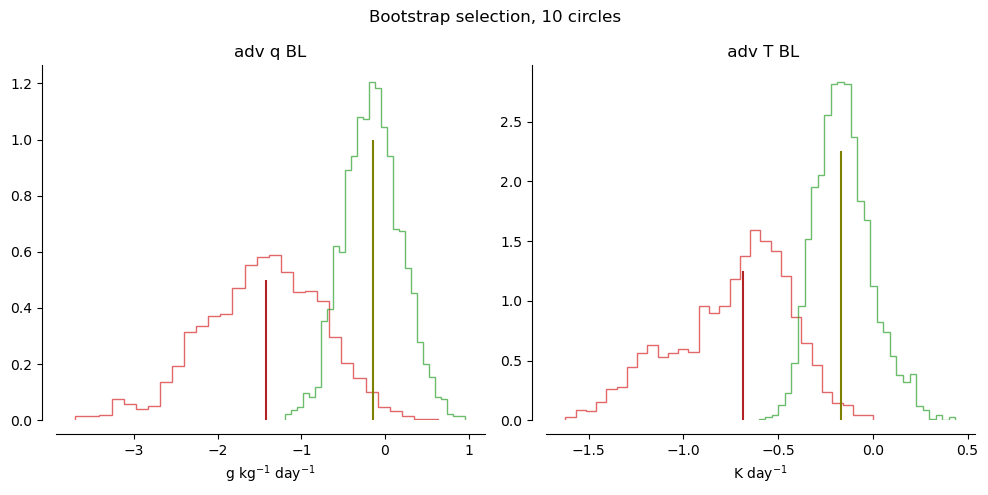

In [41]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle("Bootstrap selection, 10 circles")

(q_adv_eu_BL_boot*gkgday).plot.hist(ax=ax[0], bins=30, alpha=0.7, histtype="step", color="tab:red", density=True)
ax[0].vlines( (q_adv_eu_BL_boot*gkgday).quantile([0.5]) , ymin=0, ymax=0.5, color="firebrick", label="median")
ax[0].set_title("adv q BL")

(q_adv_or_BL_boot*gkgday).plot.hist(ax=ax[0], bins=30, alpha=0.7, histtype="step", color="tab:green", density=True)
ax[0].vlines( (q_adv_or_BL_boot*gkgday).quantile([0.5]) , ymin=0, ymax=1., color="olive", label="median")
ax[0].set_title("adv q BL")
ax[0].set_xlabel(r"$\rm g~kg^{-1}~day^{-1}$")


(T_adv_eu_BL_boot*per_day).plot.hist(ax=ax[1], bins=30, alpha=0.7, histtype="step", color="tab:red", density=True)
ax[1].vlines( (T_adv_eu_BL_boot*per_day).quantile([0.5]) , ymin=0, ymax=1.25, color="firebrick", label="median")
ax[1].set_title("adv T BL")


(T_adv_or_BL_boot*per_day).plot.hist(ax=ax[1], bins=30, alpha=0.7, histtype="step", color="tab:green", density=True)
ax[1].vlines( (T_adv_or_BL_boot*per_day).quantile([0.5]) , ymin=0, ymax=2.25, color="olive", label="median")
ax[1].set_title(" adv T BL") 

ax[1].set_xlabel(r"$\rm K~day^{-1}$")



for x in ax.flatten():
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        x.spines['left'].set_position(('outward', 10))
        x.spines['bottom'].set_position(('outward', 10))

plt.tight_layout()


##### evaluate uncertainty
a lower estimate of the error which accompanies the advection estimate is (provided circles are uncorrelated to each other)

$$ \sigma_{A,\psi} = \sqrt{ \left( \frac{\partial A}{\partial (\partial_x \psi)} \sigma_{e, \partial_x \psi} \right)^2 + \left( \frac{\partial A}{\partial (\partial_y \psi)} \sigma_{e, \partial_x \psi} \right)^2 } $$

In [ ]:
def estimate_std_error_adv(u_mean, v_mean, dPsidx_std_error, dPsidy_std_error):
    return ( (u_mean*dPsidx_std_error )**2  + (v_mean*dPsidy_std_error)**2 )**0.5

# JOANNE
sigma_qAdv_joanne = estimate_std_error_adv(joanne.u, joanne.v, joanne.se_dqdx, joanne.se_dqdy)
sigma_TAdv_joanne = estimate_std_error_adv(joanne.u, joanne.v, joanne.se_dtadx, joanne.se_dtady)


# BEACH
sigma_qAdv_beach = estimate_std_error_adv(beach.u.sel(sonde=0), beach.v.sel(sonde=0), beach.q_dqdx_std_error.sel(sonde=0), beach.q_dqdy_std_error.sel(sonde=0))
sigma_TAdv_beach = estimate_std_error_adv(beach.u.sel(sonde=0), beach.v.sel(sonde=0), beach.ta_dtadx_std_error.sel(sonde=0), beach.ta_dtady_std_error.sel(sonde=0))

the error on the mean over circle is then

$$ \sigma_{A, \overline{\psi}} = \sqrt{ \frac{\sum_i \sigma^2_{i, A, \psi} }{N_{circle} - 1} } $$

/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/mh1498/m301248/conda/envs/env_hacka/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


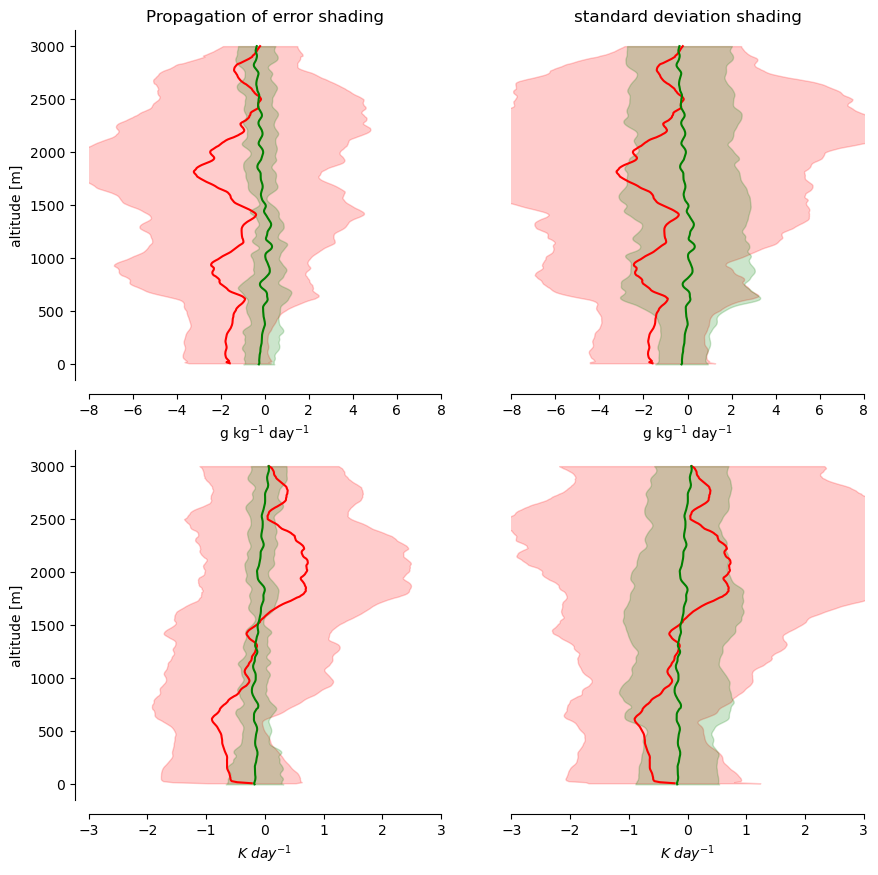

In [83]:
# JOANNE mean
sigma_qAdv_joanne_Cmean = ((sigma_qAdv_joanne**2).sum(dim="circle")/(sigma_qAdv_joanne.circle.size-1))**0.5
sigma_TAdv_joanne_Cmean = ((sigma_TAdv_joanne**2).sum(dim="circle")/(sigma_qAdv_joanne.circle.size-1))**0.5

# BEACH mean
sigma_qAdv_beach_Cmean = ((sigma_qAdv_beach**2).sum(dim="circle")/(sigma_qAdv_beach.circle.size-1))**0.5
sigma_TAdv_beach_Cmean = ((sigma_TAdv_beach**2).sum(dim="circle")/(sigma_qAdv_beach.circle.size-1))**0.5




fig, ax = plt.subplots(2,2, figsize=(10,10))


## q adv
eu_mean = (q_adv_eu*gkgday).mean(dim="circle")
or_mean = (q_adv_or*gkgday).mean(dim="circle")

eu_mean.plot.line(ax=ax[0,0], y="alt", color="red",   label="JOANNE")
or_mean.plot.line(ax=ax[0,0], y="alt", color="green",  label="BEACH")
ax[0,0].fill_betweenx(eu_mean.alt, eu_mean - sigma_qAdv_joanne_Cmean*gkgday, eu_mean + sigma_qAdv_joanne_Cmean*gkgday, color="red",   alpha=0.2)
ax[0,0].fill_betweenx(or_mean.alt, or_mean - sigma_qAdv_beach_Cmean*gkgday, or_mean + sigma_qAdv_beach_Cmean*gkgday, color="green", alpha=0.2)

ax[0,0].set_xlim(-8., 8.)
ax[0,0].set_title("Propagation of error shading")
ax[0,0].set_xlabel(r"$\rm g~kg^{-1}~day^{-1}$")



eu_mean = (q_adv_eu*gkgday).mean(dim="circle")
eu_std  = (q_adv_eu*gkgday).std(dim="circle")

or_mean = (q_adv_or*gkgday).mean(dim="circle")
or_std  = (q_adv_or*gkgday).std(dim="circle")

eu_mean.plot.line(ax=ax[0,1], y="alt", color="red",   label="JOANNE")
or_mean.plot.line(ax=ax[0,1], y="alt", color="green",  label="BEACH")
ax[0,1].fill_betweenx(eu_mean.alt, eu_mean - eu_std, eu_mean + eu_std, color="red",   alpha=0.2)
ax[0,1].fill_betweenx(or_mean.alt, or_mean - or_std, or_mean + or_std, color="green", alpha=0.2)

ax[0,1].set_xlim(-8., 8.)
ax[0,1].set_title("standard deviation shading")
ax[0,1].set_xlabel(r"$\rm g~kg^{-1}~day^{-1}$")
ax[0,1].spines["left"].set_visible(False)
ax[0,1].yaxis.set_visible(False)







## T adv
eu_mean = (T_adv_eu*per_day).mean(dim="circle")
or_mean = (T_adv_or*per_day).mean(dim="circle")

eu_mean.plot.line(ax=ax[1,0], y="alt", color="red",   label="JOANNE")
or_mean.plot.line(ax=ax[1,0], y="alt", color="green",  label="BEACH")
ax[1,0].fill_betweenx(eu_mean.alt, eu_mean - sigma_TAdv_joanne_Cmean*per_day, eu_mean + sigma_TAdv_joanne_Cmean*per_day, color="red",   alpha=0.2)
ax[1,0].fill_betweenx(or_mean.alt, or_mean - sigma_TAdv_beach_Cmean*per_day, or_mean + sigma_TAdv_beach_Cmean*per_day, color="green", alpha=0.2)

ax[1,0].set_xlim(-3., 3.)
ax[1,0].set_xlabel(r"$K~day^{-1}$")





eu_mean = (T_adv_eu*per_day).mean(dim="circle")
eu_std  = (T_adv_eu*per_day).std(dim="circle")

or_mean = (T_adv_or*per_day).mean(dim="circle")
or_std  = (T_adv_or*per_day).std(dim="circle")

eu_mean.plot.line(ax=ax[1,1], y="alt", color="red",   label="JOANNE")
or_mean.plot.line(ax=ax[1,1], y="alt", color="green",  label="BEACH")
ax[1,1].fill_betweenx(eu_mean.alt, eu_mean - eu_std, eu_mean + eu_std, color="red",   alpha=0.2)
ax[1,1].fill_betweenx(or_mean.alt, or_mean - or_std, or_mean + or_std, color="green", alpha=0.2)

ax[1,1].set_xlim(-3., 3.)
ax[1,1].set_xlabel(r"$K~day^{-1}$")
ax[1,1].spines["left"].set_visible(False)
ax[1,1].yaxis.set_visible(False)

for x in ax.flatten():
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        x.spines['left'].set_position(('outward', 10))
        x.spines['bottom'].set_position(('outward', 10))

In [4]:
beach_3 = xr.open_dataset("ipfs://bafybeiczbv7mycr2jois6t4dq3zwiltycomwo5xxvjqcjz2ot3newzar6q", engine="zarr")
beach_3
lon_condition = (beach_3.launch_lon < -40) & (beach_3.launch_lon < -40)
beach_3 = beach_3.rename({'altitude': 'alt'}).where(lon_condition, drop=True)


joanne_3 = xr.open_dataset("/work/mh1498/m301248/TCO_data/dropsondes/EUREC4A/EUREC4A_JOANNE_Dropsonde-RD41_Level_3_v2.0.0.nc")

In [5]:
entrainment_levels = slice(600, 850)
mixed_avg_levels   = slice(200,400)

downdraft_levels_eu = slice(1000, 2000)    
downdraft_levels_or = slice(2500, 3500)

cp = 1004.
Lv = 2.5e6
g = 9.81

In [ ]:
## compute thetaD
from scipy.optimize import root_scalar

def pot_temp_from_h(theta, p, h_cd, Lv, cp):
    es = 6.1121 * np.exp(17.502 * (theta-273.15) / (240.97 + (theta-273.15)))
    denominator = p - 0.378 * es * (1.0007 + p * 3.46e-6)
    
    return h_cd/cp - theta - (Lv / cp) * 0.622 * es * (1.0007 + p * 3.46e-6) / denominator

# single profile, different levels
def find_theta_for_pair(p, h):
    # def f(t):
    #     return temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)
    
    f = lambda t : pot_temp_from_h(t, p=p, h_cd=h, Lv=Lv, cp=cp)

    try:
        sol = root_scalar(f, bracket=[275,300], method='brentq')
        return sol.root if sol.converged else np.nan
    except Exception as e:
        print(f"Exception for p={p:.2f}, h={h:.2f}: {e}")
        return np.nan

# since I am working with arrays
vectorized_theta_root = np.vectorize(find_theta_for_pair)



def properties_from_profile(profile, mixed_avg_levels, entrainment_levels, downdraft_levels, vert_dim):

    h_cd = (cp*profile["ta"] + Lv*profile["q"] + g*profile[vert_dim]).sel({vert_dim:downdraft_levels})
    p_cd = profile["p"].sel({vert_dim:downdraft_levels}).values

    thetaD = np.nanmean(vectorized_theta_root( p_cd / 100., h_cd))
    qD = np.nanmean(meteo.qsea(   (thetaD)-273.15 , p_cd/100.  )/1e3)

    theta_out = profile.theta.sel({vert_dim:entrainment_levels}).mean(dim = vert_dim)
    theta_bl  = profile.theta.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim)

    q_out = profile.q.sel({vert_dim:entrainment_levels}).mean(dim = vert_dim)
    q_bl  = profile.q.sel({vert_dim:mixed_avg_levels}).mean(dim = vert_dim)

    cd_levels = profile[vert_dim].sel({vert_dim:downdraft_levels}).values

    return xr.Dataset(dict(
    thetaD=xr.DataArray(thetaD, dims=[vert_dim], coords={vert_dim:cd_levels}),
    qD=xr.DataArray(qD, dims=[vert_dim], coords={vert_dim:cd_levels}),
    theta_out=theta_out,
    theta_bl=theta_bl,
    q_out=q_out,
    q_bl=q_bl
))

In [7]:
subJoanne_3 = joanne_3.isel(sonde_id=slice(0,-1, 12))

E_CD_j3 = xr.concat(
    map(lambda i: properties_from_profile(subJoanne_3.isel(sonde_id=i), downdraft_levels_eu, vert_dim="alt"),
        range(subJoanne_3.sizes["sonde_id"])),
        dim=subJoanne_3["sonde_id"]
)



subBeach_3 = beach_3.isel(sonde=slice(0,-1, 12))

E_CD_b3 = xr.concat(
    map(lambda i: properties_from_profile(subBeach_3.isel(sonde=i), downdraft_levels_or, vert_dim="alt"),
        range(subBeach_3.sizes["sonde"])),
    dim=subBeach_3["sonde"]
)

/tmp/ipykernel_167033/3367456212.py:3: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  E_CD_j3 = xr.concat(


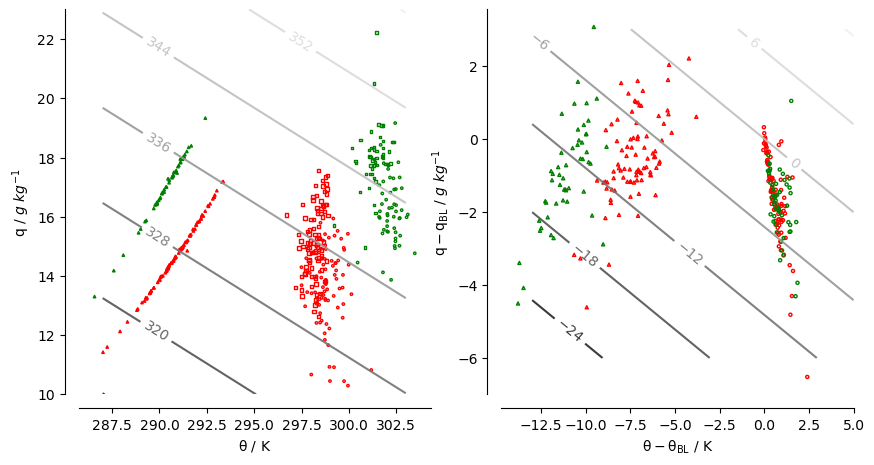

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

th, q = np.linspace(287, 303), np.linspace(0.01*1e3, 0.023*1e3)
dth, dq = np.linspace(-13, 5), np.linspace(-6.e-3*1e3, (3e-3)*1e3)
Th, Q = np.meshgrid(th, q)
DTh, DQ = np.meshgrid(dth, dq)

MSE  = (cp*Th + Lv*Q/1e3)/cp
DMSE = (cp*DTh + Lv*DQ/1e3)/cp



# absolute coords (ax[0])
ax[0].scatter(E_CD_j3["theta_bl"],        E_CD_j3["q_bl"]*1e3,       s=6,  facecolors="none",      marker="s", edgecolors="red")
ax[0].scatter(E_CD_j3["theta_out"], E_CD_j3["q_out"]*1e3, marker="o",s=3,  facecolors="none",edgecolors="red",)
ax[0].scatter(E_CD_j3["thetaD"],   E_CD_j3["qD"]*1e3,  marker="^", s=3, facecolors="none",edgecolors="red",)
ax[0].set_xlabel(r"$\rm \theta$ / K")
ax[0].set_ylabel(r"$\rm q$ / $g~kg^{-1}$")

# absolute coords (ax[0])
ax[0].scatter(E_CD_b3["theta_bl"],        E_CD_b3["q_bl"]*1e3,     s=3,  facecolors="none",       marker="s", edgecolors="green")
ax[0].scatter(E_CD_b3["theta_out"], E_CD_b3["q_out"]*1e3, marker="o", s=3, facecolors="none",edgecolors="green",)
ax[0].scatter(E_CD_b3["thetaD"],   E_CD_b3["qD"]*1e3,  marker="^", s=3, facecolors="none",edgecolors="green",)


cs = ax[0].contour(Th, Q, MSE, cmap="Greys_r", alpha=0.9)
ax[0].clabel(cs, inline=True)






# absolute coords (ax[0])
# ax[1].scatter(0,                0,        facecolors="none",      marker="s", edgecolors="red")
ax[1].scatter((E_CD_j3["theta_out"] - E_CD_j3["theta_bl"]), (E_CD_j3["q_out"] - E_CD_j3["q_bl"])*1e3, s=5, marker="o", facecolors="none",edgecolors="red",)
ax[1].scatter((E_CD_j3["thetaD"] - E_CD_j3["theta_bl"]),   (E_CD_j3["qD"] - E_CD_j3["q_bl"])*1e3, s=5,  marker="^", facecolors="none",edgecolors="red",)
ax[1].set_xlabel(r"$\rm \theta - \theta_{BL}$ / K")
ax[1].set_ylabel(r"$\rm q - q_{BL}$ / $g~kg^{-1}$")

# absolute coords (ax[0])
# ax[1].scatter(0,0,      facecolors="none",       marker="s", edgecolors="green")
ax[1].scatter((E_CD_b3["theta_out"]- E_CD_b3["theta_bl"]), (E_CD_b3["q_out"] - E_CD_b3["q_bl"])*1e3, s=5, marker="o", facecolors="none",edgecolors="green",)
ax[1].scatter((E_CD_b3["thetaD"]- E_CD_b3["theta_bl"]),   (E_CD_b3["qD"] - E_CD_b3["q_bl"])*1e3, s=5,  marker="^", facecolors="none",edgecolors="green",)

cs = ax[1].contour(DTh, DQ, DMSE, cmap="Greys_r", alpha=0.9)
ax[1].clabel(cs, inline=True)



for x in ax.flatten():
    for spine in ['top', 'right']:
        x.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        x.spines['left'].set_position(('outward', 10))
        x.spines['bottom'].set_position(('outward', 10))


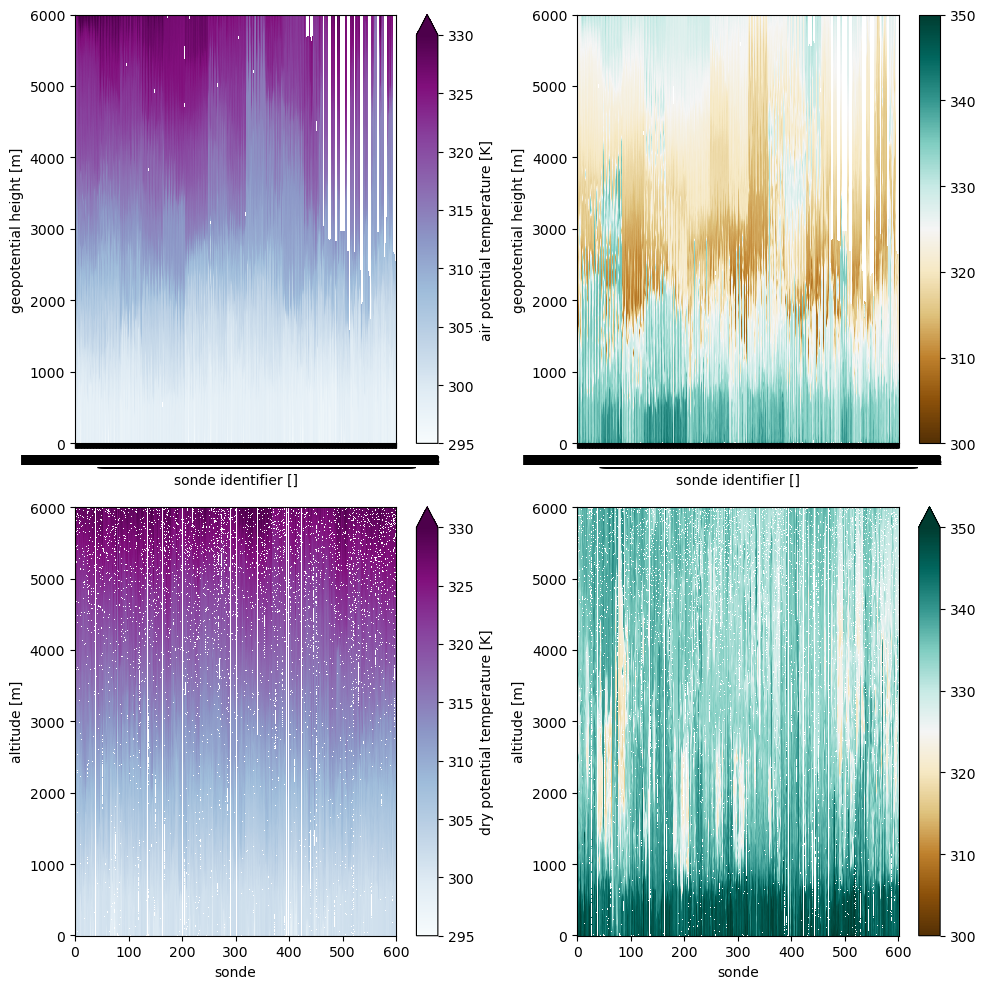

In [26]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
ax = ax.flatten()

joanne_3.theta.sel(alt=slice(0,6000)).plot.pcolormesh(ax=ax[0], y="alt", cmap="BuPu", vmin=295, vmax=330)
( joanne_3.theta + (Lv/cp)*joanne_3.q).sel(alt=slice(0,6000)).plot.pcolormesh(ax=ax[1], y="alt", cmap="BrBG", vmin=300, vmax=350)

beach_3.theta.sel(alt=slice(0,6000)).plot.pcolormesh(ax=ax[2], y="alt", cmap="BuPu", vmin=295, vmax=330)
( beach_3.theta + (Lv/cp)*beach_3.q ).sel(alt=slice(0,6000)).plot.pcolormesh(ax=ax[3], y="alt", cmap="BrBG", vmin=300, vmax=350)


plt.tight_layout()

### reconstruct this figure
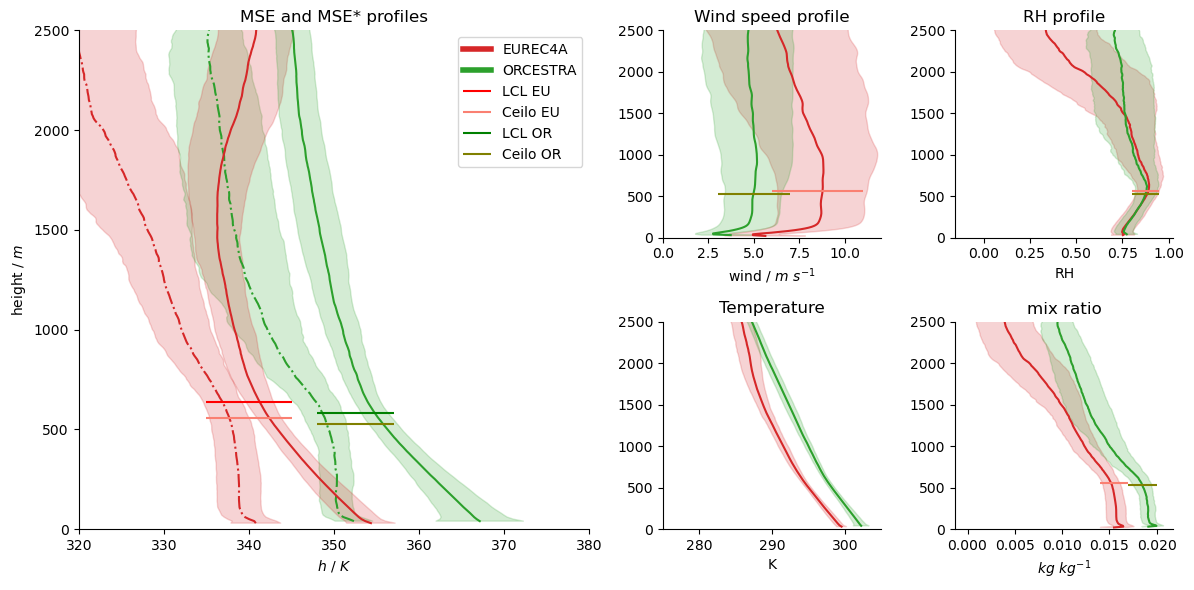

#### with radiosonde

In [126]:
joanne_3 = xr.open_dataset("/work/mh1498/m301248/TCO_data/dropsondes/EUREC4A/EUREC4A_JOANNE_Dropsonde-RD41_Level_3_v2.0.0.nc")
joanne_3 = joanne_3.sel(alt=slice(0,3000))


groups = np.arange(len(joanne_3.sonde_id)) // 12
joanne_3 = joanne_3.assign_coords(circle=('sonde_id', groups)).groupby('circle').mean()

joanne_3

<xarray.Dataset> Size: 2MB
Dimensions:          (circle: 89, alt: 301, nv: 2)
Coordinates:
  * circle           (circle) int64 712B 0 1 2 3 4 5 6 ... 82 83 84 85 86 87 88
  * alt              (alt) int16 602B 0 10 20 30 40 ... 2960 2970 2980 2990 3000
Dimensions without coordinates: nv
Data variables: (12/22)
    p                (circle, alt) float32 107kB nan 1.012e+05 ... 7.137e+04
    ta               (circle, alt) float32 107kB nan 299.4 299.3 ... 281.7 281.7
    rh               (circle, alt) float32 107kB nan 0.7751 ... 0.3181 0.3165
    wspd             (circle, alt) float32 107kB nan 9.254 9.686 ... 5.762 5.778
    wdir             (circle, alt) float32 107kB nan 72.64 74.62 ... 183.1 184.4
    u                (circle, alt) float32 107kB nan -8.765 ... 0.3054 0.4399
    ...               ...
    N_gps            (circle, alt) float32 107kB nan 1.5 1.833 ... 1.0 2.0 1.5
    m_p              (circle, alt) float32 107kB nan 1.5 2.0 ... 1.0 2.0 1.5
    m_ta             (circle, alt) float32 107kB nan 1.5 2.0 ... 1.0 2.0 1.5
    m_rh             (circle, alt) float32 107kB nan 1.545 1.917 ... 1.0 2.0 1.5
    m_gps            (circle, alt) float32 107kB nan 1.545 1.833 ... 1.0 2.0 1.5
    alt_bnds         (circle, alt, nv) int32 214kB -5 5 5 15 ... 2995 2995 3005
Attributes: (12/16)
    title:                   EUREC4A JOANNE Level-3
    doi:                     10.25326/246
    created with:            run_joanne.py doi:10.5281/zenodo.5521192
    Conventions:             CF-1.8
    campaign_id:             EUREC4A
    project_id:              JOANNE
    ...                      ...
    JOANNE_version:          2.0.0
    author:                  Geet George
    author_email:            geet.george@mpimet.mpg.de
    featureType:             trajectory
    reference:               George et al., JOANNE : Joint dropsonde Observat...
    creation_time:           2021-09-22 14:35:24.817595 UTC

In [128]:
cp = 1004   # J / kg K
Lv = 2.5e6  # J / kg
g  = 9.81   # m/s2  



mse_eu  = (cp*joanne_3["ta"] + Lv*joanne_3["q"] + g*joanne_3.alt)
mse_orc = (cp*beach["ta_mean"] + Lv*beach["q_mean"] + g*beach.alt).sel(sonde=0).squeeze()

mse_sat_eu  = (cp*joanne_3["ta"] + Lv*joanne_3["q"]/joanne_3["rh"] + g*joanne_3.alt)
mse_sat_orc = (cp*beach["ta_mean"] + Lv*beach["q_mean"]/beach["rh"] + g*beach.alt).sel(sonde=0).squeeze()

## --- MSE
mse_eu_mean =  mse_eu.mean(dim="circle")
mse_orc_mean = mse_orc.mean(dim="circle")

mse_eu_std =  mse_eu.std(dim="circle")
mse_orc_std = mse_orc.std(dim="circle")


## --- MSE sat
mse_sat_eu_mean =  mse_sat_eu.mean(dim="circle")
mse_sat_orc_mean = mse_sat_orc.mean(dim="circle")

mse_sat_eu_std =  mse_sat_eu.std(dim="circle")
mse_sat_orc_std = mse_sat_orc.std(dim="circle")

In [124]:
## add mean LCL to plot
cbh_eu_ds = xr.open_dataset("/work/mh1498/m301248/TCO_data/cbh_data/EU_cbh_lcl_windowed_quantiles.nc")
lcl_eu =  cbh_eu_ds.lcl_quantiles.isel(quantile_lcl=0).mean(dim="launch_time")
cbh_eu =  cbh_eu_ds.cbh_quantiles.isel(quantile=0).mean(dim="launch_time")

cbh_or_ds = xr.open_dataset("/work/mh1498/m301248/TCO_data/cbh_data/OR_cbh_lcl_windowed_quantiles.nc")
lcl_or = cbh_or_ds.lcl_quantiles.isel(quantile_lcl=0).mean(dim="launch_time")
cbh_or = cbh_or_ds.cbh_quantiles.isel(quantile=0).mean(dim="launch_time")

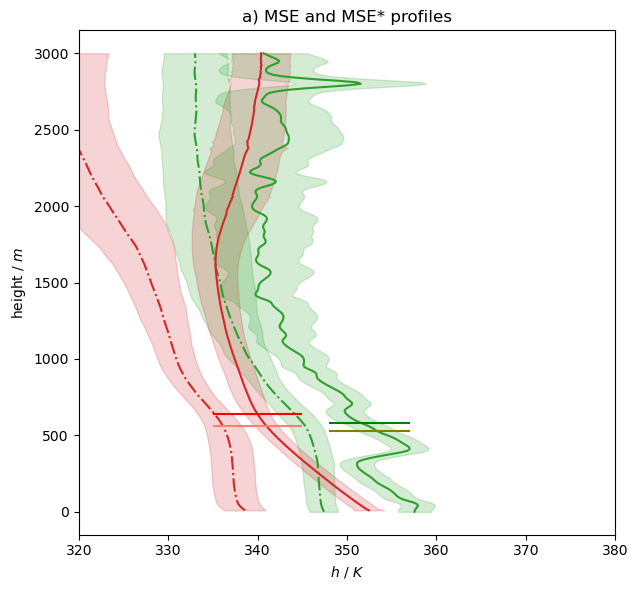

In [ ]:
import matplotlib.gridspec as gridspec


import warnings
warnings.filterwarnings("ignore")



fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 4)  # 1 row, 4 columns
top_lim = 2500

# Large subplot spanning columns 0 and 1
ax_big = fig.add_subplot(gs[:, 0:2])  # Spans columns 0 and 1 in row 0

# - mse plots
ax_big.plot( mse_eu_mean/cp,   mse_eu_mean.alt,  linestyle='-.', color="tab:red", label="EUREC4A")
ax_big.plot( mse_orc_mean/cp,  mse_orc_mean.alt, linestyle='-.', color="tab:green", label="ORCESTRA")

ax_big.fill_betweenx(
    mse_eu_mean.alt,
    (mse_eu_mean - mse_eu_std)/cp ,
    (mse_eu_mean + mse_eu_std)/cp ,
    color="tab:red",
    alpha=0.2,
    label='±1 std (time)'
)

ax_big.fill_betweenx(
    mse_orc_mean.alt,
    (mse_orc_mean - mse_orc_std)/cp ,
    (mse_orc_mean + mse_orc_std)/cp ,
    color="tab:green",
    alpha=0.2,
    label='±1 std (time)'
)

## - saturated mse plots
ax_big.plot( mse_sat_eu_mean/cp,   mse_sat_eu_mean.alt, linestyle='-', color="tab:red", label="EUREC4A")
ax_big.plot( mse_sat_orc_mean/cp, mse_sat_orc_mean.alt, linestyle='-', color="tab:green", label="ORCESTRA")

ax_big.fill_betweenx(
    mse_sat_eu_mean.alt,
    (mse_sat_eu_mean - mse_sat_eu_std)/cp ,
    (mse_sat_eu_mean + mse_sat_eu_std)/cp ,
    color="tab:red",
    alpha=0.2,
    label='±1 std (time)'
)

ax_big.fill_betweenx(
    mse_sat_orc_mean.alt,
    (mse_sat_orc_mean - mse_sat_orc_std)/cp ,
    (mse_sat_orc_mean + mse_sat_orc_std)/cp ,
    color="tab:green",
    alpha=0.2,
    label='±1 std (time)'
)



## add cbh info - cbh_eu
l1 = ax_big.hlines(lcl_eu, xmin=335, xmax=345, color="red", label="LCL EU")
l2 = ax_big.hlines(cbh_eu, xmin=335, xmax=345, color="salmon", label="Ceilo EU")

l3 = ax_big.hlines(lcl_or, xmin=348, xmax=357, color="green", label="LCL OR")
l4 = ax_big.hlines(cbh_or, xmin=348, xmax=357, color="olive", label="Ceilo OR")


# - axis properties
ax_big.set_xlabel(r"$h$ / $K$")
ax_big.set_ylabel(r"height / $m$")
ax_big.set_title("a) MSE and MSE* profiles")
ax_big.set_xlim(320,380)




# ## - wspd 
# ax3 = fig.add_subplot(gs[0, 2])
# ax3.set_title("Subplot 3")
# ax3.plot(ds_eureca["wspd"].mean(dim="sounding"), ds_eureca.alt,  color="tab:red", label="EU")
# ax3.plot(ds_orcestra_bco["wspd"].mean(dim="launch_time"), ds_orcestra_bco.height, color="tab:green", label="OR")


# ax3.fill_betweenx(
#     ds_eureca.alt,
#     (ds_eureca["wspd"].mean(dim="sounding") - ds_eureca["wspd"].std(dim="sounding")) ,
#     (ds_eureca["wspd"].mean(dim="sounding") + ds_eureca["wspd"].std(dim="sounding")) ,
#     color="tab:red",
#     alpha=0.2,
#     label='±1 std (time)'
# )

# ax3.fill_betweenx(
#     ds_orcestra_bco.height,
#     (ds_orcestra_bco["wspd"].mean(dim="launch_time") - ds_orcestra_bco["wspd"].std(dim="launch_time")) ,
#     (ds_orcestra_bco["wspd"].mean(dim="launch_time") + ds_orcestra_bco["wspd"].std(dim="launch_time")) ,
#     color="tab:green",
#     alpha=0.2,
#     label='±1 std (time)'
# )


# ax3.hlines(cbh_eu, xmin=6, xmax=11, color="salmon", label="Ceilo EU")
# ax3.hlines(cbh_or, xmin=3, xmax=7, color="olive", label="Ceilo OR")

# ax3.set_xlabel(r"wind / $m~s^{-1}$")
# ax3.set_title("b) Wind speed profile")
# ax3.set_xlim(0,12)



# # RH
# ax4 = fig.add_subplot(gs[0, 3])
# ax4.set_title("Subplot 4")
# ax4.plot(ds_eureca["rh"].mean(dim="sounding"), ds_eureca.alt, color="tab:red", label="EU")
# ax4.plot(ds_orcestra_bco["rh"].mean(dim="launch_time"), ds_orcestra_bco.height, color="tab:green", label="OR")

# ax4.fill_betweenx(
#     ds_eureca.alt,
#     (ds_eureca["rh"].mean(dim="sounding") - ds_eureca["rh"].std(dim="sounding")) ,
#     (ds_eureca["rh"].mean(dim="sounding") + ds_eureca["rh"].std(dim="sounding")) ,
#     color="tab:red",
#     alpha=0.2,
#     label='±1 std (time)'
# )

# ax4.fill_betweenx(
#     ds_orcestra_bco.height,
#     (ds_orcestra_bco["rh"].mean(dim="launch_time") - ds_orcestra_bco["rh"].std(dim="launch_time")) ,
#     (ds_orcestra_bco["rh"].mean(dim="launch_time") + ds_orcestra_bco["rh"].std(dim="launch_time")) ,
#     color="tab:green",
#     alpha=0.2,
#     label='±1 std (time)'
# )

# ax4.hlines(cbh_eu, xmin=0.8, xmax=0.95, color="salmon", label="Ceilo EU")
# ax4.hlines(cbh_or, xmin=0.8, xmax=0.95, color="olive", label="Ceilo OR")

# ax4.set_xlabel(r"RH")
# ax4.set_title("c) RH profile")






# # Temperature
# ax5 = fig.add_subplot(gs[1, 2])
# ax5.plot(ds_eureca["ta"].mean(dim="sounding"), ds_eureca.alt, color="tab:red", label="EU")
# ax5.plot(ds_orcestra_bco["ta"].mean(dim="launch_time"), ds_orcestra_bco.height, color="tab:green", label="OR")

# ax5.fill_betweenx(
#     ds_eureca.alt,
#     (ds_eureca["ta"].mean(dim="sounding") - ds_eureca["ta"].std(dim="sounding")) ,
#     (ds_eureca["ta"].mean(dim="sounding") + ds_eureca["ta"].std(dim="sounding")) ,
#     color="tab:red",
#     alpha=0.2,
#     label='±1 std (time)'
# )

# ax5.fill_betweenx(
#     ds_orcestra_bco.height,
#     (ds_orcestra_bco["ta"].mean(dim="launch_time") - ds_orcestra_bco["ta"].std(dim="launch_time")) ,
#     (ds_orcestra_bco["ta"].mean(dim="launch_time") + ds_orcestra_bco["ta"].std(dim="launch_time")) ,
#     color="tab:green",
#     alpha=0.2,
#     label='±1 std (time)'
# )

# ax5.set_xlabel(r"K")
# ax5.set_title("d) Temperature")
# ax5.set_xlim(275,305)


# # moisture
# ax6 = fig.add_subplot(gs[1, 3])
# ax6.plot(ds_eureca["mr"].mean(dim="sounding"), ds_eureca.alt, color="tab:red", label="EU")
# ax6.plot(ds_orcestra_bco["mr"].mean(dim="launch_time"), ds_orcestra_bco.height, color="tab:green", label="OR")

# ax6.fill_betweenx(
#     ds_eureca.alt,
#     (ds_eureca["mr"].mean(dim="sounding") - ds_eureca["mr"].std(dim="sounding")) ,
#     (ds_eureca["mr"].mean(dim="sounding") + ds_eureca["mr"].std(dim="sounding")) ,
#     color="tab:red",
#     alpha=0.2,
#     label='±1 std (time)'
# )

# ax6.fill_betweenx(
#     ds_orcestra_bco.height,
#     (ds_orcestra_bco["mr"].mean(dim="launch_time") - ds_orcestra_bco["mr"].std(dim="launch_time")) ,
#     (ds_orcestra_bco["mr"].mean(dim="launch_time") + ds_orcestra_bco["mr"].std(dim="launch_time")) ,
#     color="tab:green",
#     alpha=0.2,
#     label='±1 std (time)'
# )


# ax6.hlines(cbh_eu, xmin=14e-3, xmax=17e-3, color="salmon", label="Ceilo EU")
# ax6.hlines(cbh_or, xmin=17e-3, xmax=20e-3, color="olive", label="Ceilo OR")

# ax6.set_xlabel(r"$kg~kg^{-1}$")
# ax6.set_title("e) mix ratio")






# ## - esthetics

# legend_elements = [
#     Line2D([0], [0], color='tab:red', lw=4, label='EUREC4A'),
#     Line2D([0], [0], color='tab:green', lw=4, label='ORCESTRA'), 
#     l1, l2, l3, l4
# ]
# ax_big.legend(handles=legend_elements, loc='best')

# axes = []
# axes.append(ax_big)
# axes.append(ax3)
# axes.append(ax4)
# axes.append(ax5)
# axes.append(ax6)
# for x in axes:
#     x.set_ylim(0,top_lim)
#     # x.hlines(y=600, xmin=x.get_xlim()[0], xmax=x.get_xlim()[1])
#     for spine in ['top', 'right']:
#         x.spines[spine].set_visible(False)


plt.tight_layout()
plt.show()
